In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from statsmodels.stats.multitest import multipletests
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed

from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
import cmlreaders as cml

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option('display.max_columns', None)

In [2]:
EXP = 'CourierReinstate1'
SUBJECTS = ['LTP564', 'LTP565', 'LTP566', 'LTP567', 'LTP568', 'LTP569', 'LTP571', 'LTP572', 'LTP573',
            'LTP574', 'LTP575', 'LTP576', 'LTP577', 'LTP578', 'LTP579', 'LTP580', 'LTP581', 'LTP583',
            'LTP584', 'LTP585', 'LTP586', 'LTP587', 'LTP588', 'LTP589', 'LTP590', 'LTP591', 'LTP592', 
            'LTP593', 'LTP594', 'LTP595', 'LTP596', 'LTP597', 'LTP598', 'LTP599', 'LTP600', 'LTP601', 
            'LTP602', 'LTP603', 'LTP604', 'LTP605']

REL_START, REL_STOP = 300, 1300
BUFFER_MS = 1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

In [3]:
def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [4]:
df_idx = cml.get_data_index('ltp').query("experiment == @EXP").copy()
if SUBJECTS is not None:
    df_idx = df_idx[df_idx['subject'].isin(SUBJECTS)]
subjects = sorted(df_idx.subject.unique())
print(f'Found {len(subjects)} subjects for experiment "{EXP}".')

Found 40 subjects for experiment "CourierReinstate1".


In [5]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    """
    All arrays are shape (n_channels, n_freqs) or scalars broadcastable thereto.
    Returns t of shape (n_channels, n_freqs).
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [6]:
def process_subject_stats(subject, EXP=EXP, batch=BATCH_EVENTS):
    """
    Returns DataFrame: subject, channel, frequency, t
    Aggregates across ALL sessions for that subject using event-batched processing.
    """
    # Query sessions
    sessions = cml.get_data_index('ltp').query(
        "experiment == @EXP and subject == @subject"
    ).session.unique()

    # Aggregators per-channel (dict of channel -> arrays of len(FREQS))
    n1, n0 = {}, {}          # counts
    sum1, sum0 = {}, {}      # sums
    sumsq1, sumsq0 = {}, {}  # sum of squares
    freq_vec = FREQS         # store once

    for sess in sessions:
        ret_evs = None
        delib_evs = None
        try:
            reader = cml.CMLReader(subject=subject, experiment=EXP, session=sess)
            evs_all = reader.load('task_events')
            evs_all = evs_all[(evs_all['type']=='WORD') & (evs_all['eegoffset']>=0)]
            if evs_all.empty:
                continue

            # Process events in batches to keep memory low
            for start in range(0, len(evs_all), batch):
                evs = evs_all.iloc[start:start+batch]
                rec_mask = evs['recalled'].to_numpy().astype(bool)

                eeg = reader.load_eeg(
                    evs, rel_start=-BUFFER_MS, rel_stop=REL_STOP + BUFFER_MS, clean='LCF'
                ).to_ptsa()

                # Notch filter
                eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg)

                # Wavelet power for this batch
                mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output='power', complete=True)
                pwr = mw.filter(eeg).sel(time=slice(REL_START, REL_STOP)).mean(dim='time')  # (event, channel, frequency)

                # Move to numpy: (E, C, F)
                p = pwr.transpose('event', 'channel', 'frequency').values
                chans = pwr['channel'].values

                # Initialize per-channel accumulators as needed
                for ci, ch in enumerate(chans):
                    if ch not in n1:
                        z = np.zeros(len(freq_vec), dtype=np.float64)
                        n1[ch] = 0; n0[ch] = 0
                        sum1[ch] = z.copy(); sum0[ch] = z.copy()
                        sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

                # Update recalled group
                if rec_mask.any():
                    vals = p[rec_mask]                      # (Er, C, F)
                    s = vals.sum(axis=0)                    # (C, F)
                    ss = (vals**2).sum(axis=0)             # (C, F)
                    cnt = rec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum1[ch]   += s[ci]
                        sumsq1[ch] += ss[ci]
                        n1[ch]     += cnt

                # Update non-recalled group
                nrec_mask = ~rec_mask
                if nrec_mask.any():
                    vals = p[nrec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals**2).sum(axis=0)
                    cnt = nrec_mask.sum()
                    for ci, ch in enumerate(chans):
                        sum0[ch]   += s[ci]
                        sumsq0[ch] += ss[ci]
                        n0[ch]     += cnt

                # Free batch memory early
                del eeg, pwr, p
                gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    # Build channel × freq arrays and compute Welch t
    if not n1:
        return pd.DataFrame(columns=['subject','channel','frequency','t'])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i,:]  = n1[ch];   N0[i,:]  = n0[ch]
        S1[i,:]  = sum1[ch]; S0[i,:]  = sum0[ch]
        SS1[i,:] = sumsq1[ch]; SS0[i,:] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)  # (C, F)

    df = (pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=['channel','frequency']),
            columns=['t']
         ).reset_index())
    df['subject'] = subject
    return df

In [7]:
client = da.new_dask_client_slurm(
    job_name="encoding",
    memory_per_job="50GB",
    max_n_jobs=10,
    queue="RAM",
    local_directory="",
    log_directory="dask_logs"
)

Unique port for joycerose14 is 51609
{'dashboard_address': ':51609'}
To view the dashboard, run: 
`ssh -fN joycerose14@rhino2.psych.upenn.edu -L 8000:192.168.86.106:51609` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [8]:
futures = [client.submit(process_subject_stats, s, EXP, BATCH_EVENTS) for s in subjects]

In [9]:
subj_chan_t_list, n_done, n_fail = [], 0, 0
for fut in as_completed(futures):
    try:
        df = fut.result()
        subj_chan_t_list.append(df)
        n_done += 1
        sub = df['subject'].iat[0] if not df.empty else 'EMPTY_SUBJECT'
        print(f"[DONE] {n_done}/{len(subjects)} :: {sub} (rows={len(df)})")
    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")

[DONE] 1/40 :: LTP565 (rows=5888)
[DONE] 2/40 :: LTP564 (rows=5888)
[DONE] 3/40 :: LTP567 (rows=5888)
[DONE] 4/40 :: LTP576 (rows=5888)
[DONE] 5/40 :: LTP578 (rows=5888)
[DONE] 6/40 :: LTP583 (rows=5888)
[DONE] 7/40 :: LTP580 (rows=5888)
[DONE] 8/40 :: EMPTY_SUBJECT (rows=0)
[DONE] 9/40 :: LTP569 (rows=5888)
[DONE] 10/40 :: LTP566 (rows=5888)
[DONE] 11/40 :: LTP574 (rows=5888)
[DONE] 12/40 :: LTP572 (rows=5888)
[DONE] 13/40 :: LTP585 (rows=5888)
[DONE] 14/40 :: LTP586 (rows=5888)
[DONE] 15/40 :: LTP592 (rows=5888)
[DONE] 16/40 :: LTP577 (rows=5888)
[DONE] 17/40 :: LTP593 (rows=5888)
[DONE] 18/40 :: LTP575 (rows=5888)
[DONE] 19/40 :: LTP581 (rows=5888)
[DONE] 20/40 :: LTP600 (rows=5888)
[DONE] 21/40 :: LTP588 (rows=5888)
[DONE] 22/40 :: LTP568 (rows=5888)
[DONE] 23/40 :: LTP573 (rows=5888)
[DONE] 24/40 :: LTP571 (rows=5888)
[DONE] 25/40 :: LTP587 (rows=5888)
[DONE] 26/40 :: LTP590 (rows=5888)
[DONE] 27/40 :: LTP584 (rows=5888)
[DONE] 28/40 :: LTP589 (rows=5888)
[DONE] 29/40 :: LTP602 (r

In [16]:
client.shutdown()

In [17]:
chan_t_all = (pd.concat(subj_chan_t_list, ignore_index=True)
              if subj_chan_t_list else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
print("Combined channel×freq rows:", len(chan_t_all))

Combined channel×freq rows: 229632


In [18]:
chan_t_all['ROI'] = chan_t_all['channel'].map(assign_roi)
chan_t_all = chan_t_all.dropna(subset=['ROI']).copy()

subj_roi_t = (chan_t_all
              .groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [19]:
def one_samp(s):
    s = s.dropna()
    if s.empty: return pd.Series({'t_mean':np.nan,'p':np.nan})
    t_mean = s.mean()
    _, p = stats.ttest_1samp(s, 0.0, nan_policy='omit')
    return pd.Series({'t_mean':t_mean, 'p':p})

In [20]:
mean_tbl = (subj_roi_t
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long = (subj_roi_t
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg = mean_tbl.merge(p_tbl_long, on=['ROI','frequency'], how='outer')

heat = agg.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat.columns]
if cols_present:
    heat = heat[cols_present]

p_tbl = agg.pivot(index='frequency', columns='ROI', values='p')
if cols_present:
    p_tbl = p_tbl[cols_present]

rej, p_adj, *_ = multipletests(p_tbl.values.ravel(), method='fdr_bh')
p_adj_tbl = pd.DataFrame(p_adj.reshape(p_tbl.shape),
                         index=p_tbl.index, columns=p_tbl.columns)

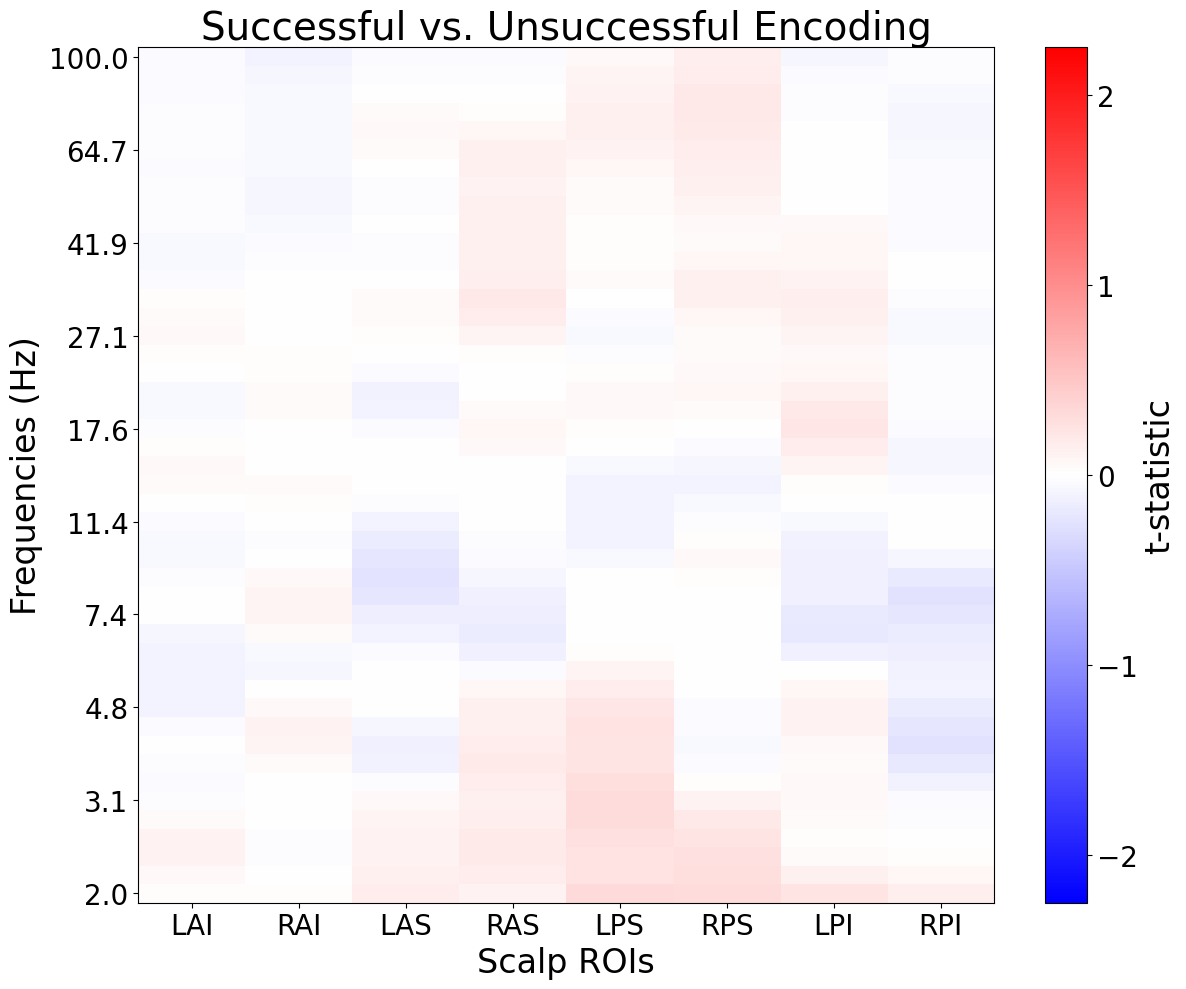

In [21]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat, cmap='bwr', aspect='auto', norm=norm)

freqs = heat.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(list(heat.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful vs. Unsuccessful Encoding', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', size=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)

# sig = (p_adj_tbl.loc[heat.index, heat.columns].values < 0.05)
# for (i, j), ok in np.ndenumerate(sig):
#     if ok:
#         ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, lw=1.5, edgecolor='k'))

plt.tight_layout()
plt.show()